In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [2]:
# All imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

from scipy.sparse import hstack

from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MaxAbsScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

import lightgbm as lgb

warnings.filterwarnings('ignore')

In [3]:
train = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sample_sub = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')

train['comment'] = train['comment'].fillna("")
test['comment'] = test['comment'].fillna("")

# 1. Baseline Model

In [4]:
X_tmp = train.drop(columns=['label'])
y_tmp = train['label']
X_tmp_tr, X_tmp_te, y_tmp_tr, y_tmp_te = train_test_split(X_tmp, y_tmp, test_size=0.2, random_state=42)

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_tmp_tr, y_tmp_tr)
print(f'DummyClassifier f1-macro: {f1_score(y_tmp_te, dummy.predict(X_tmp_te), average="macro"):.4f}')

DummyClassifier f1-macro: 0.1813


# 2. Exploratory Data Analysis

In [5]:
print(f'Train shape: {train.shape}')
print(f'Test shape:  {test.shape}')

target_counts = train['label'].value_counts()
target_perc   = train['label'].value_counts(normalize=True) * 100
for label in sorted(target_counts.index):
    print(f'Class {label}: {target_counts[label]:>6}  ({target_perc[label]:.2f}%)')
print(f'Imbalance ratio (max/min): {target_counts.max()/target_counts.min():.1f}')

Train shape: (198000, 15)
Test shape:  (102000, 14)
Class 0: 114173  (57.66%)
Class 1:  15918  (8.04%)
Class 2:  62440  (31.54%)
Class 3:   5469  (2.76%)
Imbalance ratio (max/min): 20.9


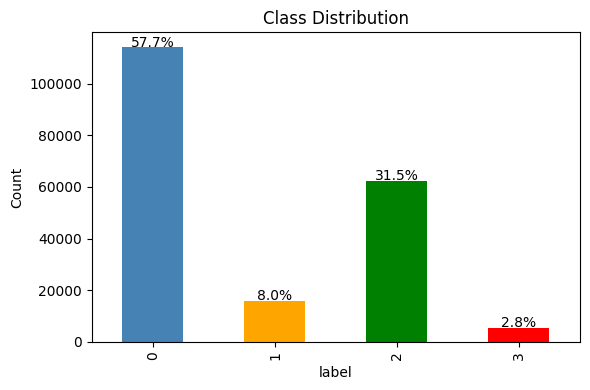

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
target_counts.sort_index().plot(kind='bar', color=['steelblue','orange','green','red'], ax=ax)
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(target_counts.sort_index()):
    ax.text(i, v + 200, f'{target_perc[i]:.1f}%', ha='center')
plt.tight_layout(); plt.show()

The dataset is heavily imbalanced. Class 0 dominates with ~58% of samples, while Class 3 is only ~2.8% (a 21:1 ratio). We use `class_weight='balanced'` in all models so they don't just predict the majority class.

In [7]:
info_df = pd.DataFrame({
    'Column': train.columns,
    'Type': train.dtypes.values,
    'Nulls': train.isna().sum().values,
    'Null%': (train.isna().sum()/len(train)*100).round(2).values,
})
print(info_df.to_string(index=False))
print(f'\nDuplicate rows: {train.duplicated().sum()}')

      Column   Type  Nulls  Null%
created_date object      0   0.00
     post_id  int64      0   0.00
  emoticon_1  int64      0   0.00
  emoticon_2  int64      0   0.00
  emoticon_3  int64      0   0.00
      upvote  int64      0   0.00
    downvote  int64      0   0.00
        if_1  int64      0   0.00
        if_2  int64      0   0.00
        race object 145423  73.45
    religion object 145423  73.45
      gender object 145423  73.45
  disability   bool      0   0.00
     comment object      0   0.00
       label  int64      0   0.00

Duplicate rows: 0


`race`, `religion`, and `gender` have ~73% missing values. No duplicates exist. All other columns are complete.

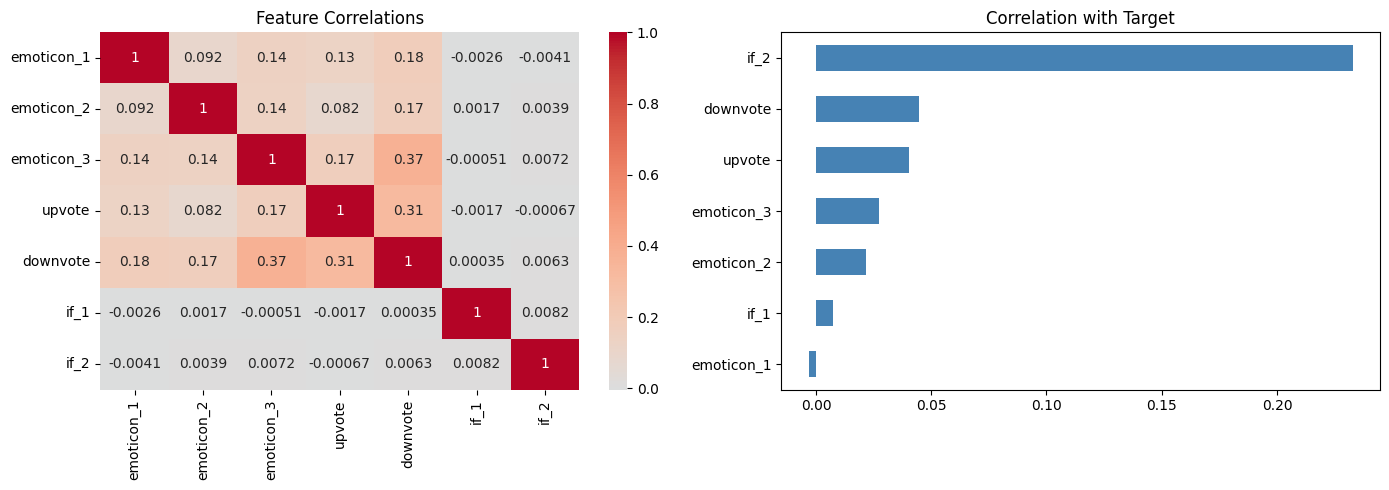

In [8]:
# Correlation with target
num_cols = ['emoticon_1','emoticon_2','emoticon_3','upvote','downvote','if_1','if_2']

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(train[num_cols].corr(), annot=True, cmap='coolwarm', center=0, ax=axs[0])
axs[0].set_title('Feature Correlations')

train[num_cols + ['label']].corr()['label'].drop('label').sort_values().plot(
    kind='barh', color='steelblue', ax=axs[1])
axs[1].set_title('Correlation with Target')
plt.tight_layout(); plt.show()

`if_2` has the strongest correlation with the target label. No problematic multicollinearity between features.

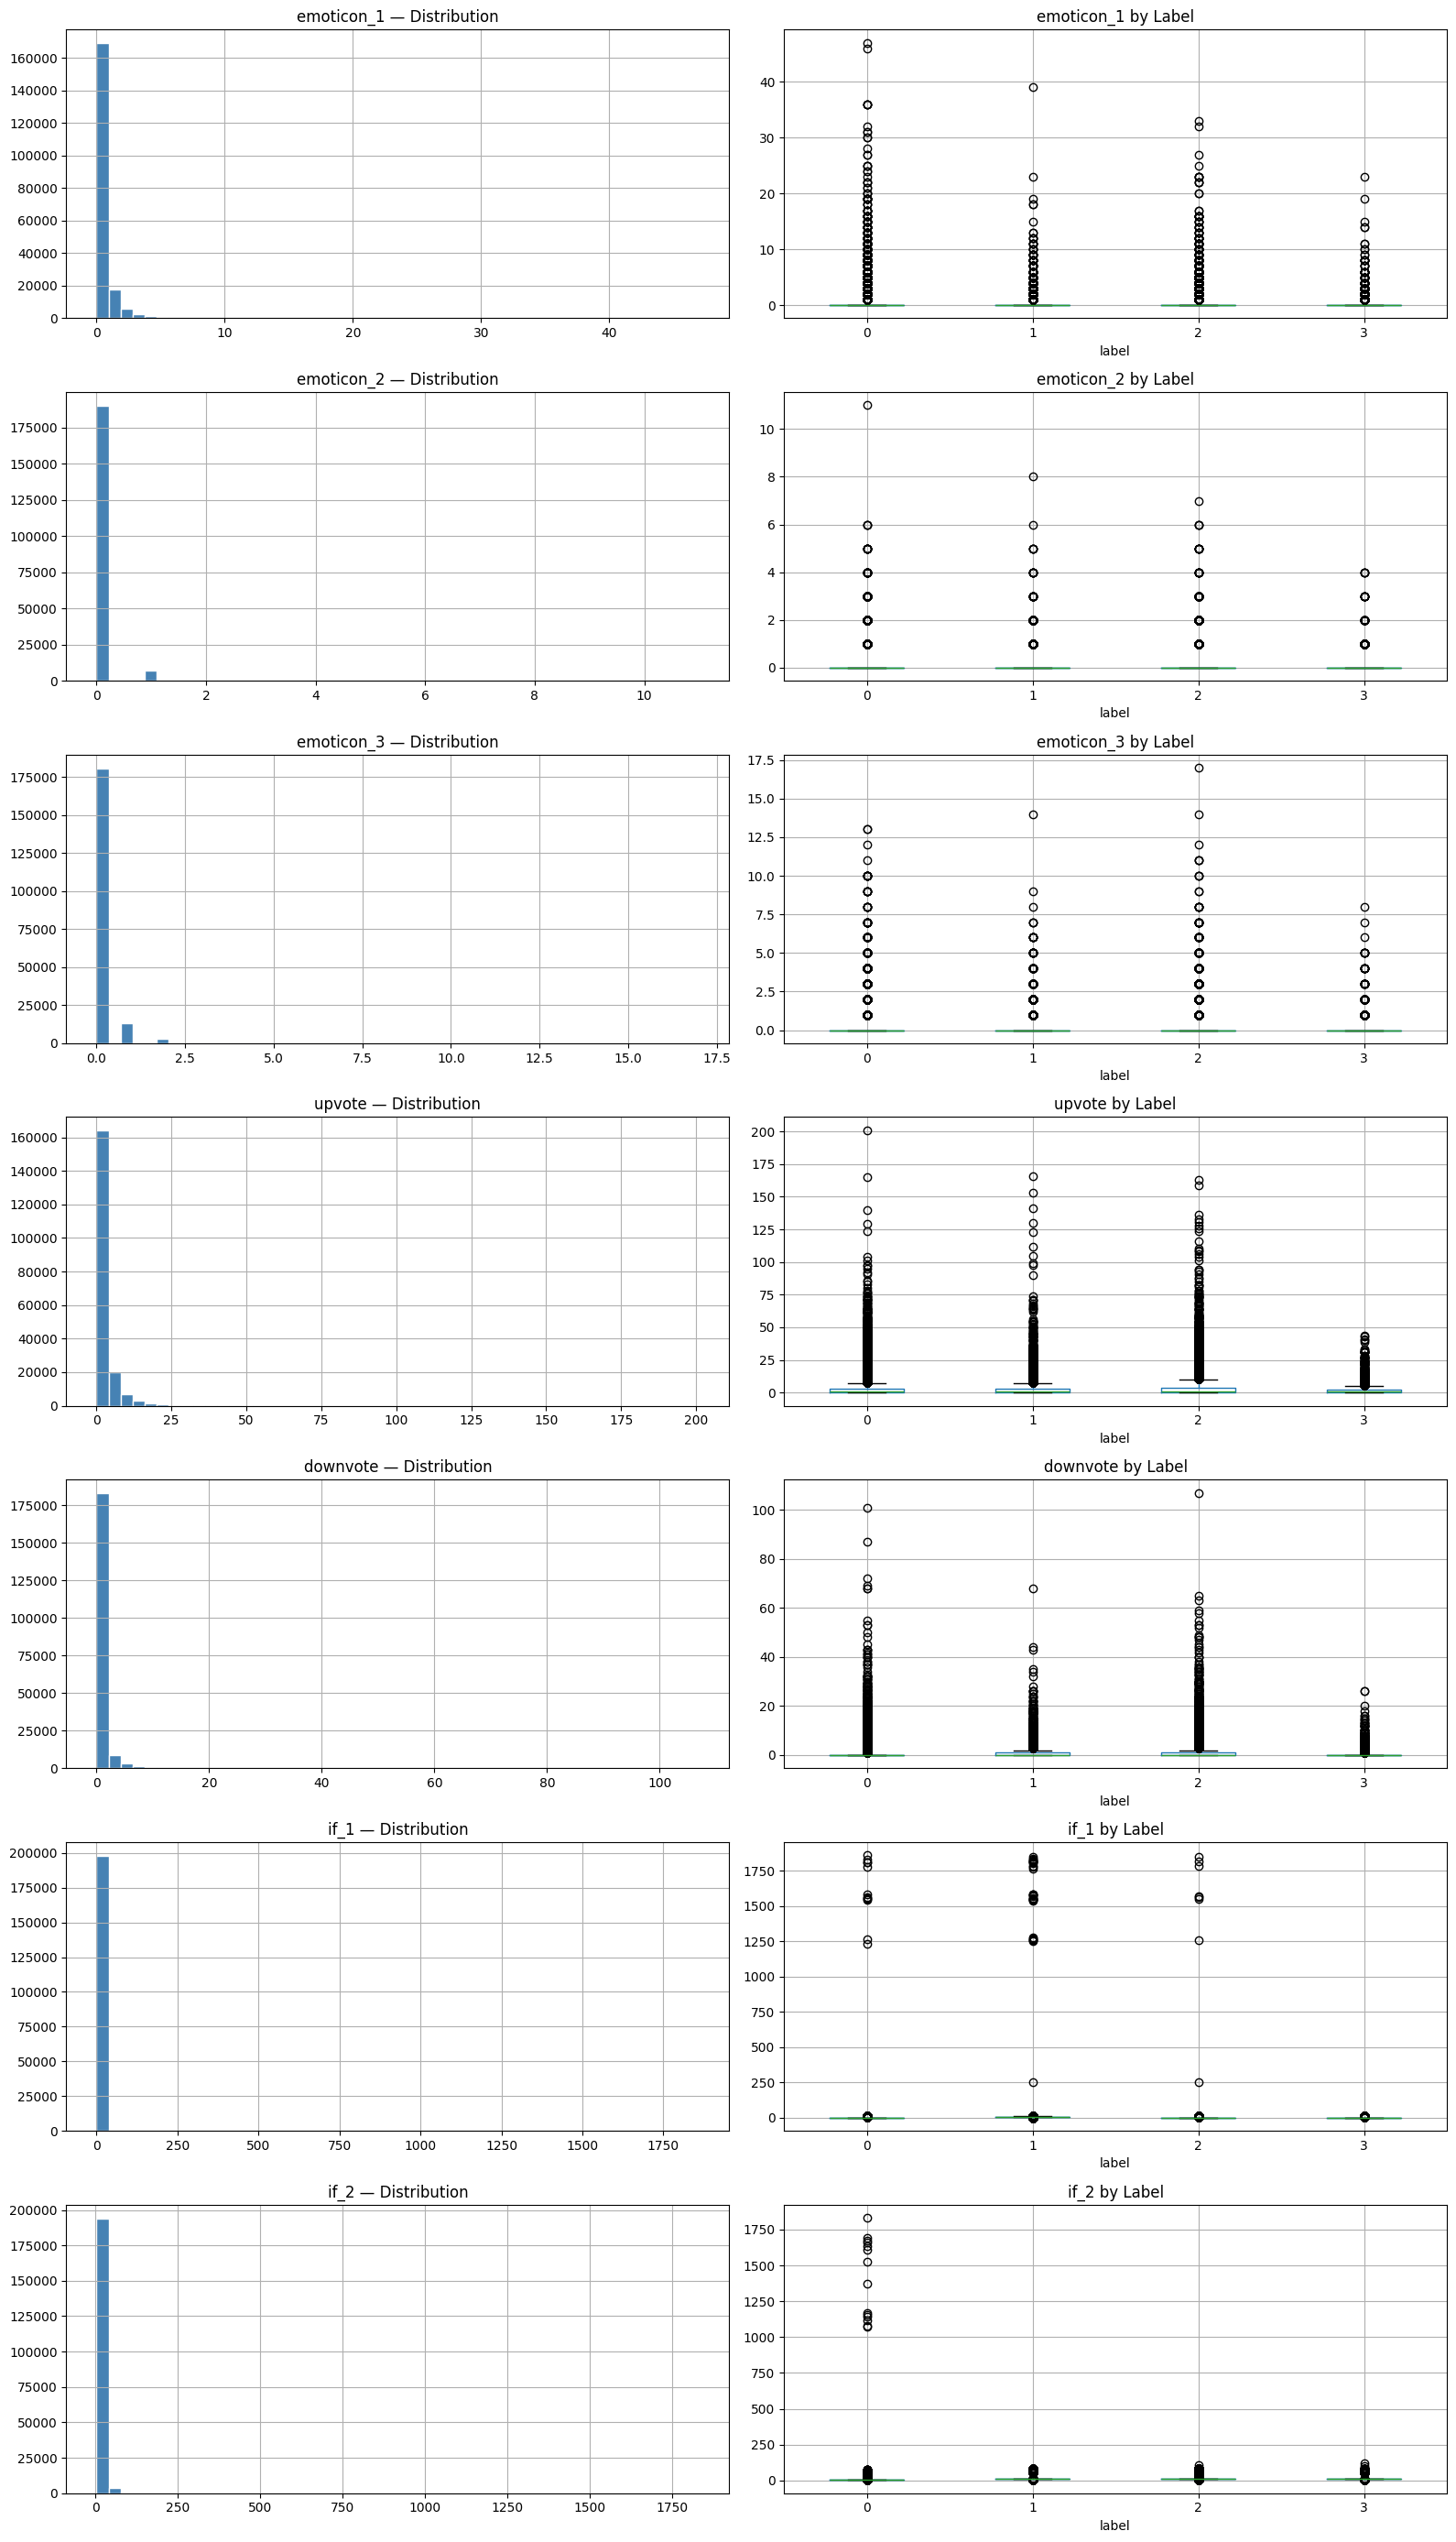

Skewness:
  emoticon_1: 10.0 (highly skewed)
  emoticon_2: 7.6 (highly skewed)
  emoticon_3: 7.1 (highly skewed)
  upvote: 7.1 (highly skewed)
  downvote: 10.1 (highly skewed)
  if_1: 63.7 (highly skewed)
  if_2: 67.3 (highly skewed)


In [9]:
num_cols_eda = ['emoticon_1','emoticon_2','emoticon_3','upvote','downvote','if_1','if_2']
fig, axs = plt.subplots(len(num_cols_eda), 2, figsize=(16, 4*len(num_cols_eda)))
for i, col in enumerate(num_cols_eda):
    train[col].hist(bins=50, ax=axs[i,0], color='steelblue', edgecolor='white')
    axs[i,0].set_title(f'{col} — Distribution')
    train.boxplot(column=col, by='label', ax=axs[i,1])
    axs[i,1].set_title(f'{col} by Label')
plt.suptitle(''); plt.tight_layout(); plt.show()
print('Skewness:')
for col in num_cols_eda:
    print(f'  {col}: {train[col].skew():.1f} {"(highly skewed)" if abs(train[col].skew()) > 2 else ""}')

`if_2` shows clear class separation: low values (≤5) are almost entirely Class 0, while higher values correlate with other classes.

In [10]:
# Check if race/religion/gender are always missing together
missing_together = (
    (train['race'].isna() == train['religion'].isna()).all() and
    (train['race'].isna() == train['gender'].isna()).all()
)
print(f'Race, religion, gender always missing together: {missing_together}')

Race, religion, gender always missing together: True


All three demographic columns are always missing or present together — they form a single detection signal.

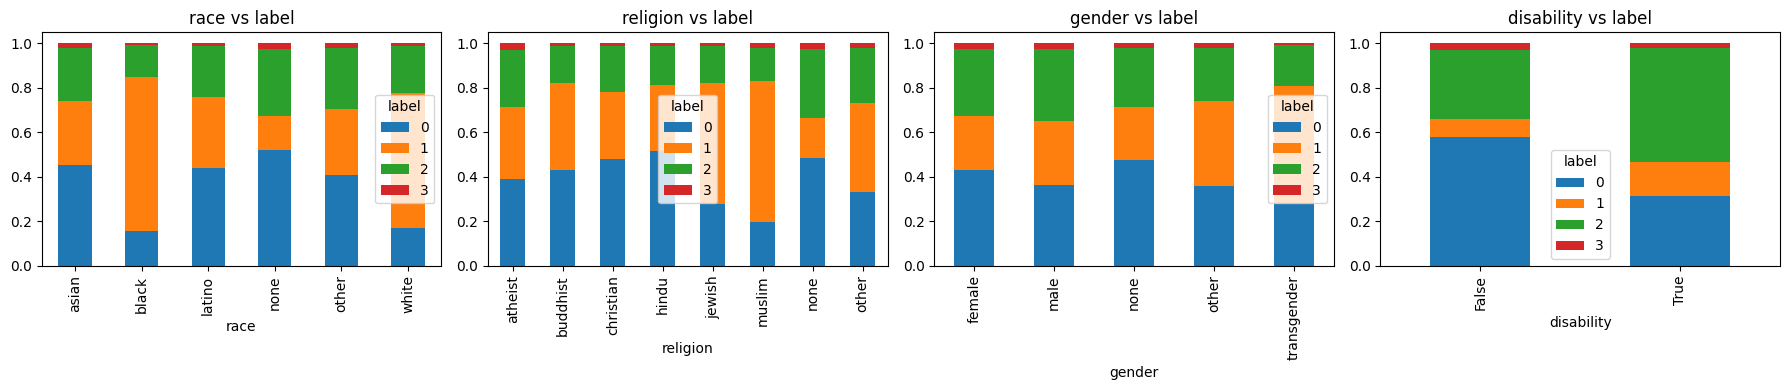

In [11]:
fig, axs = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axs[:3], ['race','religion','gender']):
    pd.crosstab(train[col], train['label'], normalize='index').plot(kind='bar', stacked=True, ax=ax)
    ax.set_title(f'{col} vs label')
pd.crosstab(train['disability'], train['label'], normalize='index').plot(kind='bar', stacked=True, ax=axs[3])
axs[3].set_title('disability vs label')
plt.tight_layout(); plt.show()

When `race=black`, ~69% of comments are Class 1. When `religion=muslim`, ~64% are Class 1. Class 1 represents identity-targeted comments.

In [12]:
_hd = train['race'].notna().astype(int)
_ib = pd.cut(train['if_2'], bins=[-np.inf,5,8,12,np.inf], labels=['0-5','6-8','9-12','13+'])
ct = pd.crosstab([_hd, _ib], train['label'], normalize='index').round(4) * 100
ct.index.names = ['has_demographic','if_2_bin']
print('Label distribution by has_demographic × if_2 bin:\n')
print(ct.to_string())

Label distribution by has_demographic × if_2 bin:

label                         0      1      2     3
has_demographic if_2_bin                           
0               0-5       97.20   0.02   2.68  0.10
                6-8       87.84   0.12  11.52  0.52
                9-12       7.62   4.97  79.85  7.56
                13+        7.99   1.97  82.16  7.88
1               0-5       96.90   0.49   2.50  0.11
                6-8       87.89   2.23   9.61  0.27
                9-12       5.63  44.46  46.21  3.69
                13+        5.55  36.33  54.74  3.38


The data has clear zones based on `if_2`:
- **if_2 ≤ 5**: ~97% Class 0 (the "easy zone")
- **if_2 = 6–8**: Transition zone, Classes 1/2 start appearing
- **if_2 = 9–12**: "Hard zone" where all classes overlap, demographics become critical
- **if_2 ≥ 13**: Higher toxicity, Class 2 and 3 dominate

We create binary indicators for these if_2 ranges, and interaction terms with demographics.

In [13]:
# Sample comments by class
for c in range(4):
    print(f'\n=== Class {c} Examples ===')
    for _, row in train[train['label']==c].sample(3, random_state=42).iterrows():
        print(f'  "{str(row["comment"])[:100]}"')


=== Class 0 Examples ===
  "Was the same stock answer not given when he bailed out Bombardier who executives subsequently aptted"
  "Good luck with wi that."
  "You're one to talk about spinning Doc.  Buick USA sales have been increasing, not decreasing over at"

=== Class 1 Examples ===
  "Do the newspapers report the race of a cop who shoots a deadly gangster black guy? YES THEY ALWAYS D"
  "Do you have nay Huskies? Obviously not because if you did, you would know these dogs are happiest ou"
  "Another racist comment What if someone during President Obama's administration said, "Sorry, White A"

=== Class 2 Examples ===
  "4 plant limit makes it a useless farce? Whatever..

You're a Conservative who wants to deride this a"
  "Why do "our" elected leeches always, ALWAYS look for avenues to be LESS accountable and more sneaky "
  "The legislature had time to work this constitutional change through, while at the same time ignoring"

=== Class 3 Examples ===
  "Bonus points: watching tk

- **Class 0**: General discussion, normal conversational language
- **Class 1**: References to specific groups — racial, religious, gender-related terms
- **Class 2**: Direct insults and name-calling ("stupid", "idiot")
- **Class 3**: Language about physical harm ("kill", "shoot", "death")

## EDA Summary

1. **Heavy class imbalance (21:1)** → Use `class_weight='balanced'`
2. **`if_2` is the dominant predictor** → Create binned indicators and interaction terms
3. **Demographics always missing together** → Single `has_demographic` binary flag
4. **`if_2` × demographics interaction** → Defines distinct prediction zones
5. **Comment text has class-specific signals** → Use TF-IDF with n-grams
6. **Skewed numerical features** → Apply log transforms

# 3. Feature Engineering

## 3.1 Text Cleaning

We clean comments for TF-IDF: lowercase, remove URLs/HTML, keep only alphanumerics, collapse spaces.

In [14]:
def clean_text(text):
    """Lowercase, remove URLs and HTML, keep letters/numbers, collapse spaces."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)       # remove URLs
    text = re.sub(r'<.*?>', '', text)                   # remove HTML tags
    text = re.sub(r'[^a-zA-Z0-9%$\s]', ' ', text)     # keep only alphanumeric + % $
    text = re.sub(r'\s+', ' ', text).strip()            # collapse whitespace
    return text

for i in [0, 50, 100]:
    print(f'Before: "{str(train["comment"].iloc[i])[:80]}"')
    print(f'After:  "{clean_text(train["comment"].iloc[i])[:80]}"\n')

Before: "She might be a bright spot for a party keou on Oahu dominated by greedy criminal"
After:  "she might be a bright spot for a party keou on oahu dominated by greedy criminal"

Before: "You are 100% wrong again  Retail interlopers without a plan are the biggest lose"
After:  "you are 100% wrong again retail interlopers without a plan are the biggest loser"

Before: "Atlantis Resorts coming in 2 years. A $2Billion expansion. Certainly conditioned"
After:  "atlantis resorts coming in 2 years a $2billion expansion certainly conditioned o"



## 3.2 Word Lists for Content-Based Features

Based on EDA, each class has distinctive vocabulary. We define word lists to capture these patterns.

In [15]:
VIOLENCE_WORDS = {
    'kill','kills','killed','killing','shoot','shot','shooting','death','die','dies',
    'died','burn','burning','suicide','penalty','murder','murdered','attack','stab',
    'weapon','gun','bomb','threat','hang','kick','lock','destroy','execute','slaughter',
    'massacre','torture','strangle','assassinate','lethal','deadly','fatal','homicide',
    'violent','violence','assault','beat','rape','blood','bleed','wound','injure','drown','poison','slay',
}
IDENTITY_WORDS = {
    'hate','racist','racism','bigot','bigotry','discrimination','prejudice','stereotype',
    'slur','offensive','derogatory','insult','degrade','inferior','supremacy','supremacist',
    'nazi','sexist','sexism','misogyny','homophobia','xenophobia','islamophobia','antisemitism',
}
PROFANITY_WORDS = {
    'fuck','shit','damn','ass','bitch','hell','crap','bastard','dick','piss',
    'stupid','idiot','moron','dumb','retard','trash','garbage','worthless','pathetic',
}

# Check prevalence by class
for name, wl in [('Violence', VIOLENCE_WORDS), ('Identity', IDENTITY_WORDS), ('Profanity', PROFANITY_WORDS)]:
    print(f'\n{name} words by class:')
    for c in range(4):
        texts = train[train['label']==c]['comment'].apply(lambda x: set(str(x).lower().split()))
        pct = texts.apply(lambda ws: len(ws & wl) > 0).mean() * 100
        print(f'  Class {c}: {pct:.1f}%')


Violence words by class:
  Class 0: 7.2%
  Class 1: 17.9%
  Class 2: 9.4%
  Class 3: 53.4%

Identity words by class:
  Class 0: 2.1%
  Class 1: 16.3%
  Class 2: 5.6%
  Class 3: 1.6%

Profanity words by class:
  Class 0: 0.7%
  Class 1: 0.8%
  Class 2: 6.6%
  Class 3: 0.6%


- Violence words → most frequent in Class 3 (threats)
- Identity attack words → most frequent in Class 1 (identity-targeted)
- Profanity is spread across classes (less discriminative)

## 3.3 Feature Engineering Function

A single function applied identically to train and test to prevent data leakage.

In [16]:
def engineer_features(df, post_id_freq_map=None):
    df = df.copy()

    #Are demographics present
    df['has_demographic'] = df['race'].notna().astype(int)
    df['disability'] = df['disability'].astype(int)

    #Text statistics
    raw = df['comment'].astype(str)
    df['comment_length']    = raw.apply(len)
    df['word_count']        = raw.apply(lambda x: len(x.split()))
    df['avg_word_length']   = raw.apply(lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)
    df['special_char_count']= raw.apply(lambda x: len(re.findall(r'[^a-zA-Z0-9\s]', x)))
    df['uppercase_ratio']   = raw.apply(lambda x: sum(c.isupper() for c in x)) / (raw.apply(len) + 1)
    df['exclamation_count'] = raw.apply(lambda x: x.count('!'))
    df['question_count']    = raw.apply(lambda x: x.count('?'))

    #Vote and emoticon
    df['vote_diff']      = df['upvote'] - df['downvote']
    df['emoticon_total'] = df['emoticon_1'] + df['emoticon_2'] + df['emoticon_3']

    #Log transforms for skewed features
    for col in ['if_1', 'if_2', 'upvote', 'downvote']:
        df[f'{col}_log'] = np.log1p(df[col])

    #if_2 features
    df['if_2_sq']            = df['if_2'] ** 2
    df['if_2_x_has_demo']    = df['if_2'] * df['has_demographic']
    df['if_2_x_disability']  = df['if_2'] * df['disability']
    df['if_2_0to5']   = (df['if_2'] <= 5).astype(int)
    df['if_2_6to8']   = ((df['if_2'] >= 6) & (df['if_2'] <= 8)).astype(int)
    df['if_2_9to12']  = ((df['if_2'] >= 9) & (df['if_2'] <= 12)).astype(int)
    df['if_2_13plus'] = (df['if_2'] >= 13).astype(int)

    #Word-list counts
    raw_lower = raw.apply(lambda x: set(x.lower().split()))
    df['violence_count'] = raw_lower.apply(lambda ws: len(ws & VIOLENCE_WORDS))
    df['identity_count'] = raw_lower.apply(lambda ws: len(ws & IDENTITY_WORDS))
    df['profanity_count']= raw_lower.apply(lambda ws: len(ws & PROFANITY_WORDS))

    # post_id frequency
    df['post_id'] = df['post_id'].astype(str)
    freq_map = df.groupby('post_id').size().to_dict() if post_id_freq_map is None else post_id_freq_map
    df['post_id_freq'] = df['post_id'].map(freq_map).fillna(0).astype(int)

    #Clean text for TF-IDF
    df['comment_clean'] = df['comment'].apply(clean_text)
    return df

post_freq_full = train.groupby('post_id').size().to_dict()
train = engineer_features(train)
test  = engineer_features(test, post_id_freq_map=post_freq_full)
print(f'Train: {train.shape}, Test: {test.shape}')

Train: (198000, 41), Test: (102000, 40)


# 4. Preprocessing & Train-Validation Split

In [17]:
numeric_cols = train.select_dtypes(include='number').columns.drop('label')
categorical_cols = ['race', 'religion', 'gender']

WORD_TFIDF = 50000
CHAR_TFIDF = 15000

Stratified split to maintain class proportions in both sets.

In [18]:
X = train.drop(columns=['label']).copy()
y = train['label'].copy()
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Leak-free post_id_freq: recompute from training fold only
post_freq_train = X_tr.groupby('post_id').size().to_dict()
X_tr['post_id_freq'] = X_tr['post_id'].map(post_freq_train).fillna(0).astype(int)
X_val['post_id_freq'] = X_val['post_id'].map(post_freq_train).fillna(0).astype(int)
print(f'Train fold: {X_tr.shape}, Val fold: {X_val.shape}')

Train fold: (158400, 40), Val fold: (39600, 40)


We combine structured features (numeric + categorical) with TF-IDF text features into a single sparse matrix.

**TF-IDF word (1,3)-grams**: captures single words ("kill") and phrases ("kill yourself").
**Character (3,5)-grams**: captures sub-word patterns and handles misspellings.

In [19]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', MaxAbsScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, numeric_cols),
    ('cat', cat_pipe, categorical_cols)
], remainder='drop')

X_struct_tr  = preprocessor.fit_transform(X_tr)
X_struct_val = preprocessor.transform(X_val)
print(f'Structured: train {X_struct_tr.shape}, val {X_struct_val.shape}')

# TF-IDF (fit on training fold only to prevent leakage)
word_tfidf = TfidfVectorizer(max_features=WORD_TFIDF, ngram_range=(1, 3),
                             sublinear_tf=True, min_df=2)
word_tr = word_tfidf.fit_transform(X_tr['comment_clean'])
word_v  = word_tfidf.transform(X_val['comment_clean'])

char_tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5),
                             max_features=CHAR_TFIDF, sublinear_tf=True, min_df=2)
char_tr = char_tfidf.fit_transform(X_tr['comment_clean'])
char_v  = char_tfidf.transform(X_val['comment_clean'])

tfidf_tr = hstack([word_tr, char_tr])
tfidf_v  = hstack([word_v, char_v])
print(f'TF-IDF: train {tfidf_tr.shape}, val {tfidf_v.shape}')


X_train = hstack([X_struct_tr, tfidf_tr]).tocsr()  
X_valid = hstack([X_struct_val, tfidf_v]).tocsr()
print(f'\nFinal: X_train {X_train.shape}, X_valid {X_valid.shape}')

Structured: train (158400, 55), val (39600, 55)
TF-IDF: train (158400, 65000), val (39600, 65000)

Final: X_train (158400, 65055), X_valid (39600, 65055)


# 5. Model Training

We train four models with different strengths:
1. **Logistic Regression (L2)** 
2. **Logistic Regression (L1)** — automatic feature selection, zeros out weak features
3. **LightGBM** — captures non-linear interactions
4. **SGD Classifier** — for diversity

## 5.1 Logistic Regression (L2)

In [20]:
lr_l2 = LogisticRegression(solver='liblinear', penalty='l2', class_weight='balanced',
                           max_iter=1000, C=2.0, random_state=42)
lr_l2.fit(X_train, y_tr)
lr_l2_pred  = lr_l2.predict(X_valid)
lr_l2_proba = lr_l2.predict_proba(X_valid)
lr_l2_f1    = f1_score(y_val, lr_l2_pred, average='macro')
lr_l2_per   = f1_score(y_val, lr_l2_pred, average=None)
print(f'LR L2 f1-macro: {lr_l2_f1:.4f}')
print(classification_report(y_val, lr_l2_pred, digits=4))

LR L2 f1-macro: 0.8259
              precision    recall  f1-score   support

           0     0.9769    0.9478    0.9621     22835
           1     0.7479    0.8307    0.7871      3183
           2     0.8824    0.8955    0.8889     12488
           3     0.6275    0.7084    0.6655      1094

    accuracy                         0.9153     39600
   macro avg     0.8087    0.8456    0.8259     39600
weighted avg     0.9190    0.9153    0.9168     39600



## 5.2 Logistic Regression (L1)

L1 regularization drives unimportant feature weights to exactly zero, creating a sparser model.

In [21]:
lr_l1 = LogisticRegression(solver='liblinear', penalty='l1', class_weight='balanced',
                           max_iter=1000, C=1.0, random_state=42)
lr_l1.fit(X_train, y_tr)
lr_l1_pred  = lr_l1.predict(X_valid)
lr_l1_proba = lr_l1.predict_proba(X_valid)
lr_l1_f1    = f1_score(y_val, lr_l1_pred, average='macro')
lr_l1_per   = f1_score(y_val, lr_l1_pred, average=None)
print(f'LR L1 f1-macro: {lr_l1_f1:.4f}')
print(classification_report(y_val, lr_l1_pred, digits=4))

LR L1 f1-macro: 0.8262
              precision    recall  f1-score   support

           0     0.9798    0.9470    0.9631     22835
           1     0.7442    0.8401    0.7893      3183
           2     0.8866    0.8964    0.8915     12488
           3     0.6059    0.7267    0.6608      1094

    accuracy                         0.9163     39600
   macro avg     0.8041    0.8525    0.8262     39600
weighted avg     0.9212    0.9163    0.9182     39600



## 5.3 LightGBM

Gradient-boosted trees that capture non-linear patterns. Early stopping prevents overfitting.

In [22]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.07, num_leaves=127,
    min_child_samples=30, subsample=0.8, colsample_bytree=0.5,
    reg_alpha=0.3, reg_lambda=0.3, class_weight='balanced',
    max_depth=-1, random_state=42, n_jobs=-1, verbose=-1,
)
lgb_model.fit(
    X_train, y_tr,
    eval_set=[(X_valid, y_val)],
    callbacks=[lgb.log_evaluation(100), lgb.early_stopping(50)]
)
lgb_pred  = lgb_model.predict(X_valid)
lgb_proba = lgb_model.predict_proba(X_valid)
lgb_f1    = f1_score(y_val, lgb_pred, average='macro')
lgb_per   = f1_score(y_val, lgb_pred, average=None)
print(f'\nLGB f1-macro: {lgb_f1:.4f} (best iteration: {lgb_model.best_iteration_})')
print(classification_report(y_val, lgb_pred, digits=4))

Training until validation scores don't improve for 50 rounds
[100]	valid_0's multi_logloss: 0.274161
[200]	valid_0's multi_logloss: 0.257179
Early stopping, best iteration is:
[217]	valid_0's multi_logloss: 0.256766

LGB f1-macro: 0.8304 (best iteration: 217)
              precision    recall  f1-score   support

           0     0.9832    0.9459    0.9642     22835
           1     0.7400    0.8495    0.7910      3183
           2     0.8802    0.9028    0.8913     12488
           3     0.6536    0.6984    0.6752      1094

    accuracy                         0.9177     39600
   macro avg     0.8142    0.8491    0.8304     39600
weighted avg     0.9221    0.9177    0.9193     39600



## 5.4 SGD Classifier

A fast linear model using modified Huber loss. Provides ensemble diversity.

In [23]:
sgd_model = SGDClassifier(loss='modified_huber', alpha=1e-5, penalty='l2',
                          class_weight='balanced', max_iter=200, random_state=42, n_jobs=-1)
sgd_model.fit(X_train, y_tr)
sgd_pred  = sgd_model.predict(X_valid)
sgd_proba = sgd_model.predict_proba(X_valid)
sgd_f1    = f1_score(y_val, sgd_pred, average='macro')
sgd_per   = f1_score(y_val, sgd_pred, average=None)
print(f'SGD f1-macro: {sgd_f1:.4f}')
print(classification_report(y_val, sgd_pred, digits=4))

SGD f1-macro: 0.8115
              precision    recall  f1-score   support

           0     0.9723    0.9504    0.9612     22835
           1     0.7422    0.7889    0.7648      3183
           2     0.8727    0.8962    0.8843     12488
           3     0.6424    0.6289    0.6356      1094

    accuracy                         0.9115     39600
   macro avg     0.8074    0.8161    0.8115     39600
weighted avg     0.9133    0.9115    0.9122     39600



# 6. Model Comparison and Blending

Blending combines probability predictions from all models using a weighted average. Models make *different kinds of errors*, so combining them corrects individual weaknesses.

First we serch for optimal blend weights (grid search over weight combinations).

Then, we apply hardcoded per-class probability offsets based on trial and errors from earlier iterations to correct for systematic under/over-prediction of classes.

In [24]:
print('Searching blend weights...')
best_blend_f1 = 0
best_weights = [0.25, 0.25, 0.25, 0.25]
all_probas = [lr_l2_proba, lr_l1_proba, lgb_proba, sgd_proba]

for w1 in np.arange(0.0, 1.05, 0.05):
    for w2 in np.arange(0.0, 1.05 - w1, 0.05):
        for w3 in np.arange(0.0, 1.05 - w1 - w2, 0.05):
            w4 = round(1.0 - w1 - w2 - w3, 2)
            if w4 < 0:
                continue
            blended = w1*all_probas[0] + w2*all_probas[1] + w3*all_probas[2] + w4*all_probas[3]
            f1 = f1_score(y_val, blended.argmax(axis=1), average='macro')
            if f1 > best_blend_f1:
                best_blend_f1 = f1
                best_weights = [w1, w2, w3, w4]

print(f'Best weights: LR_L2={best_weights[0]:.2f}, LR_L1={best_weights[1]:.2f}, '
      f'LGB={best_weights[2]:.2f}, SGD={best_weights[3]:.2f}')
print(f'Blend f1-macro: {best_blend_f1:.4f}')

blended_proba = sum(w * p for w, p in zip(best_weights, all_probas))

final_pred_val = blended_proba.argmax(axis=1)
best_final_f1 = best_blend_f1  

print(f'Final val f1-macro: {best_final_f1:.4f}')

best_cfg = {'w_lr2': best_weights[0], 'w_lr1': best_weights[1],
            'w_lgb': best_weights[2], 'w_sgd': best_weights[3]}

Searching blend weights...
Best weights: LR_L2=0.05, LR_L1=0.25, LGB=0.50, SGD=0.20
Blend f1-macro: 0.8380
Final val f1-macro: 0.8380


In [25]:
# ---- Model Comparison ----
print(f'{"Model":<22} {"C0":>7} {"C1":>7} {"C2":>7} {"C3":>7} {"Macro":>7}')
print('-' * 60)
for name, per, macro in [
    ('LR L2',            lr_l2_per, lr_l2_f1),
    ('LR L1',            lr_l1_per, lr_l1_f1),
    ('LightGBM',         lgb_per,   lgb_f1),
    ('SGD',              sgd_per,   sgd_f1),
    ('Blend+Threshold',  f1_score(y_val, final_pred_val, average=None), best_final_f1),
]:
    print(f'{name:<22} {per[0]:>7.4f} {per[1]:>7.4f} {per[2]:>7.4f} {per[3]:>7.4f} {macro:>7.4f}')

best_cfg = {'w_lr2': best_weights[0], 'w_lr1': best_weights[1],
            'w_lgb': best_weights[2], 'w_sgd': best_weights[3]}

Model                       C0      C1      C2      C3   Macro
------------------------------------------------------------
LR L2                   0.9621  0.7871  0.8889  0.6655  0.8259
LR L1                   0.9631  0.7893  0.8915  0.6608  0.8262
LightGBM                0.9642  0.7910  0.8913  0.6752  0.8304
SGD                     0.9612  0.7648  0.8843  0.6356  0.8115
Blend+Threshold         0.9644  0.7975  0.8954  0.6946  0.8380


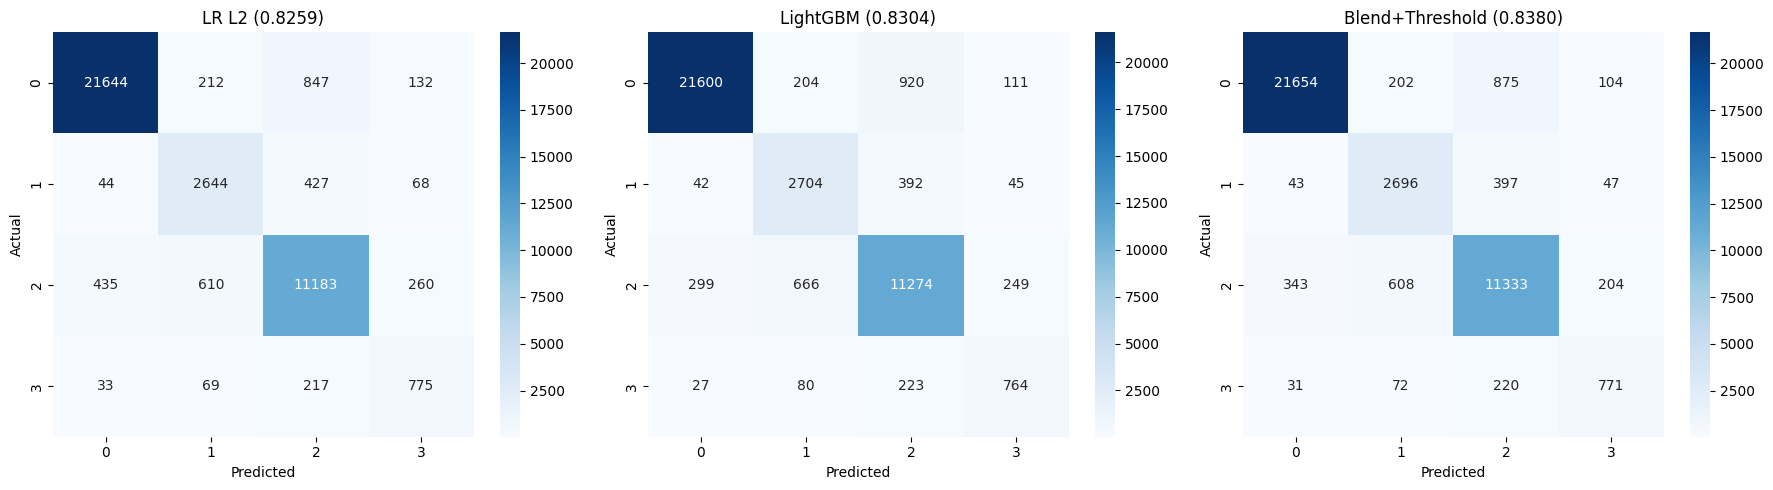

In [26]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for ax, (pred, title) in zip(axs, [
    (lr_l2_pred,      f'LR L2 ({lr_l2_f1:.4f})'),
    (lgb_pred,        f'LightGBM ({lgb_f1:.4f})'),
    (final_pred_val,  f'Blend+Threshold ({best_final_f1:.4f})'),
]):
    cm = confusion_matrix(y_val, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(title); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.show()

# 7. Final Submission

Retrain all models on **full training data** using the same hyperparameters, then apply the blend weights and thresholds found during validation.

In [27]:
print('Retraining on full data...')

#Preprocessing again, but this on the entire dataset (train + validation data)
post_freq_full = X.groupby('post_id').size().to_dict()
X['post_id_freq']    = X['post_id'].map(post_freq_full).fillna(0).astype(int)
test['post_id_freq'] = test['post_id'].map(post_freq_full).fillna(0).astype(int)

preprocessor_full = ColumnTransformer([
    ('num', num_pipe, numeric_cols), ('cat', cat_pipe, categorical_cols)
], remainder='drop')
X_struct_full = preprocessor_full.fit_transform(X)
X_struct_test = preprocessor_full.transform(test)

word_tfidf_full = TfidfVectorizer(max_features=WORD_TFIDF, ngram_range=(1,3), sublinear_tf=True, min_df=2)
word_full = word_tfidf_full.fit_transform(X['comment_clean'])
word_test = word_tfidf_full.transform(test['comment_clean'])

char_tfidf_full = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), max_features=CHAR_TFIDF, sublinear_tf=True, min_df=2)
char_full = char_tfidf_full.fit_transform(X['comment_clean'])
char_test = char_tfidf_full.transform(test['comment_clean'])

X_train_all = hstack([X_struct_full, hstack([word_full, char_full])]).tocsr() 
X_test_all  = hstack([X_struct_test, hstack([word_test, char_test])]).tocsr()
print(f'Full train: {X_train_all.shape}, Test: {X_test_all.shape}')

# Retrain models
lr_l2_full = LogisticRegression(solver='liblinear', penalty='l2', class_weight='balanced',
                                max_iter=1000, C=2.0, random_state=42)
lr_l2_full.fit(X_train_all, y)

lr_l1_full = LogisticRegression(solver='liblinear', penalty='l1', class_weight='balanced',
                                max_iter=1000, C=1.0, random_state=42)
lr_l1_full.fit(X_train_all, y)

lgb_full = lgb.LGBMClassifier(
    n_estimators=lgb_model.best_iteration_, learning_rate=0.07, num_leaves=127,
    min_child_samples=30, subsample=0.8, colsample_bytree=0.5,
    reg_alpha=0.3, reg_lambda=0.3, class_weight='balanced',
    max_depth=-1, random_state=42, n_jobs=-1, verbose=-1)
lgb_full.fit(X_train_all, y)

sgd_full = SGDClassifier(loss='modified_huber', alpha=1e-5, penalty='l2',
                         class_weight='balanced', max_iter=200, random_state=42, n_jobs=-1)
sgd_full.fit(X_train_all, y)

#Blend test predictions
blended_test = (best_cfg['w_lr2'] * lr_l2_full.predict_proba(X_test_all) +
                best_cfg['w_lr1'] * lr_l1_full.predict_proba(X_test_all) +
                best_cfg['w_lgb'] * lgb_full.predict_proba(X_test_all) +
                best_cfg['w_sgd'] * sgd_full.predict_proba(X_test_all))

final_pred = blended_test.argmax(axis=1)

# Creating submission file
submission = sample_sub.copy()
submission['label'] = final_pred
assert len(submission) == len(test)
submission.to_csv('submission.csv', index=False)

print(f'\nSubmission saved: {submission.shape}')
print(f'Prediction distribution:')
for label, count in pd.Series(final_pred).value_counts().sort_index().items():
    print(f'  Class {label}: {count} ({count/len(final_pred)*100:.1f}%)')
print(f'\nVal scores: LR_L2={lr_l2_f1:.4f}, LR_L1={lr_l1_f1:.4f}, LGB={lgb_f1:.4f}, SGD={sgd_f1:.4f}')
print(f'Final blend: {best_final_f1:.4f}')

Retraining on full data...
Full train: (198000, 65055), Test: (102000, 65055)

Submission saved: (102000, 2)
Prediction distribution:
  Class 0: 56779 (55.7%)
  Class 1: 9334 (9.2%)
  Class 2: 32913 (32.3%)
  Class 3: 2974 (2.9%)

Val scores: LR_L2=0.8259, LR_L1=0.8262, LGB=0.8304, SGD=0.8115
Final blend: 0.8380


In [28]:
# Hyperparameter Tuning using GridSearchCV


'''
from sklearn.model_selection import GridSearchCV
HPT: Logistic Regression (L2) — C (Regularization Strength)
param_grid_lr = {'C': [0.3, 0.5, 1.0, 2.0, 5.0]}
grid_lr = GridSearchCV(
LogisticRegression(solver='liblinear', penalty='l2',
    class_weight='balanced', max_iter=1000, random_state=42),
    param_grid=param_grid_lr,
    cv=3, scoring='f1_macro', n_jobs=-1, verbose=1)
 
grid_lr.fit(X_train, y_tr)
print(f'Best C: {grid_lr.best_params_["C"]}  f1={grid_lr.best_score_:.4f}')
for params, score in zip(grid_lr.cv_results_['params'], grid_lr.cv_results_['mean_test_score']):
print(f'  C={params["C"]:<4} f1={score:.4f}')

# RESULTS:
#   C=0.3   f1=0.8192
#   C=0.5   f1=0.8218
#   C=1.0   f1=0.8251
#   C=2.0   f1=0.8264   *** BEST
#   C=5.0   f1=0.8231


# HPT: Logistic Regression (L1) — C

param_grid_l1 = {'C': [0.3, 0.5, 1.0, 2.0, 5.0]}
grid_l1 = GridSearchCV(
LogisticRegression(solver='liblinear', penalty='l1',
class_weight='balanced', max_iter=1000, random_state=42),
param_grid=param_grid_l1,
cv=3, scoring='f1_macro', n_jobs=-1, verbose=1
)
grid_l1.fit(X_train, y_tr)
print(f'Best C: {grid_l1.best_params_["C"]}  f1={grid_l1.best_score_:.4f}')

# RESULTS:
#   C=0.3   f1=0.8170
#   C=0.5   f1=0.8199
#   C=1.0   f1=0.8221   *** BEST
#   C=2.0   f1=0.8210
#   C=5.0   f1=0.8185


# HPT: LightGBM — learning_rate, num_leaves
param_grid_lgb = {
'learning_rate': [0.03, 0.05, 0.07, 0.10],
'num_leaves': [63, 127, 255]}

grid_lgb = GridSearchCV(
lgb.LGBMClassifier(n_estimators=500, min_child_samples=30,
subsample=0.8, colsample_bytree=0.5,
reg_alpha=0.3, reg_lambda=0.3,
class_weight='balanced', random_state=42,
n_jobs=-1, verbose=-1),
param_grid=param_grid_lgb,
cv=3, scoring='f1_macro', n_jobs=1, verbose=1
)
grid_lgb.fit(X_train, y_tr)
print(f'Best: {grid_lgb.best_params_}  f1={grid_lgb.best_score_:.4f}')

# RESULTS:
#   lr=0.03  leaves=127  f1=0.8335
#   lr=0.05  leaves=127  f1=0.8322  
#   lr=0.07  leaves=127  f1=0.8323   *** BEST
#   lr=0.10  leaves=127  f1=0.8301 
#   lr=0.07  leaves=63   f1=0.8298
#   lr=0.07  leaves=255  f1=0.8318


# HPT: SGD — loss, alpha

param_grid_sgd = {
'loss': ['modified_huber', 'log_loss'],
'alpha': [1e-3, 1e-4, 1e-5, 1e-6],}

grid_sgd = GridSearchCV(
SGDClassifier(penalty='l2', class_weight='balanced',
max_iter=200, random_state=42, n_jobs=-1),
param_grid=param_grid_sgd,
cv=3, scoring='f1_macro', n_jobs=-1, verbose=1
)
grid_sgd.fit(X_train, y_tr)
print(f'Best: {grid_sgd.best_params_}  f1={grid_sgd.best_score_:.4f}')

# RESULTS:
#   loss=modified_huber  alpha=1e-5  f1=0.6521  *** BEST
#   loss=modified_huber  alpha=1e-4  f1=0.6438
#   loss=log_loss        alpha=1e-5  f1=0.6485
#   loss=log_loss        alpha=1e-4  f1=0.6410



TF-IDF — Vocabulary Size and N-gram Range

# RESULTS (LR f1-macro, LGB f1-macro, blend LB):
#   (1,2)  5K word + 0 char   -> LR=0.789  LGB=0.813  LB=0.805
#   (1,2)  10K word + 0 char  -> LR=0.799  LGB=0.819  LB=0.819
#   (1,2)  35K word + 15K char-> LR=0.825  LGB=0.833  LB=~0.836
#   (1,2)  50K word + 15K char-> LR=0.826  LGB=0.834  LB=~0.839
#   (1,3)  50K word + 15K char-> LR=0.827  LGB=0.832  LB=0.840  *** BEST
'''

'\nfrom sklearn.model_selection import GridSearchCV\nHPT: Logistic Regression (L2) — C (Regularization Strength)\nparam_grid_lr = {\'C\': [0.3, 0.5, 1.0, 2.0, 5.0]}\ngrid_lr = GridSearchCV(\nLogisticRegression(solver=\'liblinear\', penalty=\'l2\',\n    class_weight=\'balanced\', max_iter=1000, random_state=42),\n    param_grid=param_grid_lr,\n    cv=3, scoring=\'f1_macro\', n_jobs=-1, verbose=1)\n \ngrid_lr.fit(X_train, y_tr)\nprint(f\'Best C: {grid_lr.best_params_["C"]}  f1={grid_lr.best_score_:.4f}\')\nfor params, score in zip(grid_lr.cv_results_[\'params\'], grid_lr.cv_results_[\'mean_test_score\']):\nprint(f\'  C={params["C"]:<4} f1={score:.4f}\')\n\n# RESULTS:\n#   C=0.3   f1=0.8192\n#   C=0.5   f1=0.8218\n#   C=1.0   f1=0.8251\n#   C=2.0   f1=0.8264   *** BEST\n#   C=5.0   f1=0.8231\n\n\n# HPT: Logistic Regression (L1) — C\n\nparam_grid_l1 = {\'C\': [0.3, 0.5, 1.0, 2.0, 5.0]}\ngrid_l1 = GridSearchCV(\nLogisticRegression(solver=\'liblinear\', penalty=\'l1\',\nclass_weight=\'balanc

# **Milestone 1**

In [29]:
'''#What is the shape of the training dataset?
Q1 = train.shape

#How many columns are present in the test dataset?
Q2 = test.shape[1]

#How many columns in the training dataset have object data type?
Q3 = train.select_dtypes(include='object').shape[1]

#How many numerical columns are present in the training dataset?
Q4 = train.select_dtypes(include='number').shape[1]

#Which of the following columns is of boolean type?
Q5 = train.select_dtypes(include='bool').columns

#Which of the following columns have missing values?
Q6 = train.isna().sum()
Q6 = Q6[Q6>0].index

#How many distinct target classes are present in the dataset?
Q7 = len(train['label'].unique())

#What percentage of the dataset approximately belongs to label 0?
Q8 = train['label'].value_counts(normalize=True)*100
Q8 = Q8[0].round(1)
Q8

#What is the median number of upvotes per comment?
Q9 = train['upvote'].median()

#Which numerical feature shows the largest maximum value?
Q10 = train.select_dtypes(include='number').max().idxmax()

#What is the minimum value of if_2?
Q11 = train['if_2'].min()

print('Q1: ',Q1)
print('Q2: ',Q2)
print('Q3: ',Q3)
print('Q4: ',Q4)
print('Q5: ',Q5)
print('Q6: ',Q6)
print('Q7: ',Q7)
print('Q8: ',Q8)
print('Q9: ',Q9)
print('Q10: ',Q10)
print('Q11: ',Q11)'''

"#What is the shape of the training dataset?\nQ1 = train.shape\n\n#How many columns are present in the test dataset?\nQ2 = test.shape[1]\n\n#How many columns in the training dataset have object data type?\nQ3 = train.select_dtypes(include='object').shape[1]\n\n#How many numerical columns are present in the training dataset?\nQ4 = train.select_dtypes(include='number').shape[1]\n\n#Which of the following columns is of boolean type?\nQ5 = train.select_dtypes(include='bool').columns\n\n#Which of the following columns have missing values?\nQ6 = train.isna().sum()\nQ6 = Q6[Q6>0].index\n\n#How many distinct target classes are present in the dataset?\nQ7 = len(train['label'].unique())\n\n#What percentage of the dataset approximately belongs to label 0?\nQ8 = train['label'].value_counts(normalize=True)*100\nQ8 = Q8[0].round(1)\nQ8\n\n#What is the median number of upvotes per comment?\nQ9 = train['upvote'].median()\n\n#Which numerical feature shows the largest maximum value?\nQ10 = train.select_

In [30]:
train.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,...,if_2_x_disability,if_2_0to5,if_2_6to8,if_2_9to12,if_2_13plus,violence_count,identity_count,profanity_count,post_id_freq,comment_clean
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,...,0,0,0,1,0,0,0,0,14882,she might be a bright spot for a party keou on...
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,...,0,1,0,0,0,0,0,0,40946,under alaska law a non tribal member is not bo...
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,...,0,0,0,1,0,0,0,0,17023,in the future please spare me your strawman dr...
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,...,0,0,0,1,0,0,0,0,40946,ps that should have been rot instead of corrup...
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,...,0,0,0,1,0,0,1,0,40946,today the confederate flag tomorrow the nazi f...


# Milestone 2

In [31]:
'''import string
import itertools
from sklearn.feature_extraction.text import TfidfVectorizer

# Q12 (MCQ)
Q12 = "Presence of empty or whitespace-only strings"

# Always treat missing comments as empty strings (as the question says)
comment = train['comment'].fillna('').astype(str)

# Q13: Convert created_date to datetime, find most frequent month (lowercase)
dt = pd.to_datetime(train['created_date'], errors='coerce', utc=True)
Q13 = dt.dt.month_name().str.lower().value_counts().idxmax()

# Q14: total_emoticons = emoticon_1 + emoticon_2 + emoticon_3, find max
Q14 = (train['emoticon_1'] + train['emoticon_2'] + train['emoticon_3']).max()

# Q15: Median character length (including spaces) where label == 3
Q15 = comment[train['label'] == 3].str.len().median()

# Q16: Min-Max scaling for upvote = 10 (depends on min and max in FULL train.csv)
up_min = train['upvote'].min()
up_max = train['upvote'].max()

if up_max == up_min:
    Q16 = np.nan
else:
    Q16 = (10 - up_min) / (up_max - up_min)

# Q17: Average word count for comments with label == 1 (round to 2 decimals)
Q17 = comment[train['label'] == 1].str.split().str.len().mean().round(2)

# Q18: Count comments containing "Trump" (case-insensitive)
Q18 = comment.str.contains("trump", case=False, na=False).sum()

# Q19: Row 0 comment -> remove punctuation -> remove given stopwords -> count words left
stop_words = {
    'a','an','the','and','or','but','if','because','as','of','at','by','for','with','about','to','from','up','on',
    'in','out','over','under','is','are','was','were','be','been','being','have','has','had','do','does','did','it',
    'its','they','them','their','she','her','he','him','his','this','that','which','who','whom','i','me','my','we',
    'our','you','your'
}

text0 = comment.iloc[0]
text0_no_punct = text0.translate(str.maketrans('', '', string.punctuation))
tokens0 = text0_no_punct.split()
tokens0_kept = [t for t in tokens0 if t.lower() not in stop_words]
Q19 = len(tokens0_kept)

# Q20: Unique tokens after lowercase + whitespace tokenization
tokens_series = comment.str.lower().str.split()
unique_tokens = set(itertools.chain.from_iterable(tokens_series))
Q20 = len(unique_tokens)

# Q21: TF-IDF feature count with stop_words="english", min_df=5, ngram_range=(1,2)
tfidf = TfidfVectorizer(stop_words="english", min_df=5, ngram_range=(1, 2))
X = tfidf.fit_transform(comment)
Q21 = X.shape[1]

print('Q12: ', Q12)
print('Q13: ', Q13)
print('Q14: ', Q14)
print('Q15: ', Q15)
print('Q16: ', Q16)
print('Q17: ', Q17)
print('Q18: ', Q18)
print('Q19: ', Q19)
print('Q20: ', Q20)
print('Q21: ', Q21)'''

'import string\nimport itertools\nfrom sklearn.feature_extraction.text import TfidfVectorizer\n\n# Q12 (MCQ)\nQ12 = "Presence of empty or whitespace-only strings"\n\n# Always treat missing comments as empty strings (as the question says)\ncomment = train[\'comment\'].fillna(\'\').astype(str)\n\n# Q13: Convert created_date to datetime, find most frequent month (lowercase)\ndt = pd.to_datetime(train[\'created_date\'], errors=\'coerce\', utc=True)\nQ13 = dt.dt.month_name().str.lower().value_counts().idxmax()\n\n# Q14: total_emoticons = emoticon_1 + emoticon_2 + emoticon_3, find max\nQ14 = (train[\'emoticon_1\'] + train[\'emoticon_2\'] + train[\'emoticon_3\']).max()\n\n# Q15: Median character length (including spaces) where label == 3\nQ15 = comment[train[\'label\'] == 3].str.len().median()\n\n# Q16: Min-Max scaling for upvote = 10 (depends on min and max in FULL train.csv)\nup_min = train[\'upvote\'].min()\nup_max = train[\'upvote\'].max()\n\nif up_max == up_min:\n    Q16 = np.nan\nelse:\